In [4]:


from src.utils import utils
from src.data.data_loading import load_articles, load_links, load_unfinished_paths, load_finished_paths, load_categories

# Imports
import pandas as pd
import numpy as np
import networkx as nx

# ----------- Statistics -------------------- #
from scipy.stats import spearmanr
from scipy.stats import linregress
# Tests
from scipy.stats import chi2_contingency

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from adjustText import adjust_text

Load necessary files for analysis

In [5]:
# Load the unfinished paths dataFrame
df_unfinished = load_unfinished_paths()

# Load the finished paths dataFrame
df_finished = load_finished_paths()

# Load the categories dataframe
df_categories = load_categories()

# Load links
df_links = load_links()

# Load articles
df_articles = load_articles()

## Main and secondary categories ordered by difficulty, considering unfinished games in that category

### Ratio of unfinished games

Count number of total games and unfinished games per category

In [8]:
# UNFINISHED PATHS
# Select 'category1' and 'category 2' 
target_categories = df_unfinished['category1']
S_categories = df_unfinished['category2']

# Remove rows with NaN values
target_categories_unfinished = target_categories.dropna()
S_categories_unfinished = S_categories.dropna()

# Count number of known categories for all articles in unfinished paths
target_categories_unfinished = target_categories_unfinished.value_counts()
S_categories_unfinished = S_categories_unfinished.value_counts()


# FINISHED PATHS
# Select 'category1' and 'category 2' 
target_categories = df_finished['category1']
S_categories = df_finished['category2']

# Remove rows with NaN values
target_categories_finished = target_categories.dropna()
S_categories_finished = S_categories.dropna()

# Count number of known categories for all articles in unfinished paths
target_categories_finished = target_categories_finished.value_counts()
S_categories_finished = S_categories_finished.value_counts()


# Total number of categories for all articles
target_categories_total_count = target_categories_finished + target_categories_unfinished
S_categories_total_count = S_categories_finished + S_categories_unfinished

Ratio of unfinished paths

In [9]:
target_categories_Runf = target_categories_unfinished/target_categories_total_count
S_categories_Runf = S_categories_unfinished/S_categories_total_count

### Average difficulty

Now we will calculate the average difficulty of each category (target and secondary), and multiply it by the ratio of unfinished paths. The idea is that we want to weigh in the fact that if a category has a lot of unifinished paths, it generally means that it was difficult enough to not finish. Thus the higher the ratio, the higher the consideration for an average difficulty .

In [10]:
# Drop entries (games) with no 'rating'
df_finished_categories = df_finished.dropna(subset=['rating']).reset_index(drop=True)

# Computing average 'rating' for every category
df_Tdifficulty = df_finished [['rating','category1']]
df_Sdifficulty = df_finished[['rating', 'category2']]

Tdifficulty_target = df_Tdifficulty.groupby('category1').value_counts().unstack()
Sdifficulty_target = df_Sdifficulty.groupby('category2').value_counts().unstack()

Tweighted_sum = (Tdifficulty_target * Tdifficulty_target.columns).sum(axis=1)
Sweighted_sum = (Sdifficulty_target * Sdifficulty_target.columns).sum(axis=1)

Ttotal_count = Tdifficulty_target.sum(axis=1)
Taverage_rating = Tweighted_sum / Ttotal_count

Stotal_count = Sdifficulty_target.sum(axis=1)
Saverage_rating = Sweighted_sum / Stotal_count

### Weighed difficulty

Calculating the difficulty

In [12]:
T_weighed_rating = Taverage_rating * target_categories_Runf
S_weighed_rating = Saverage_rating * S_categories_Runf

The results

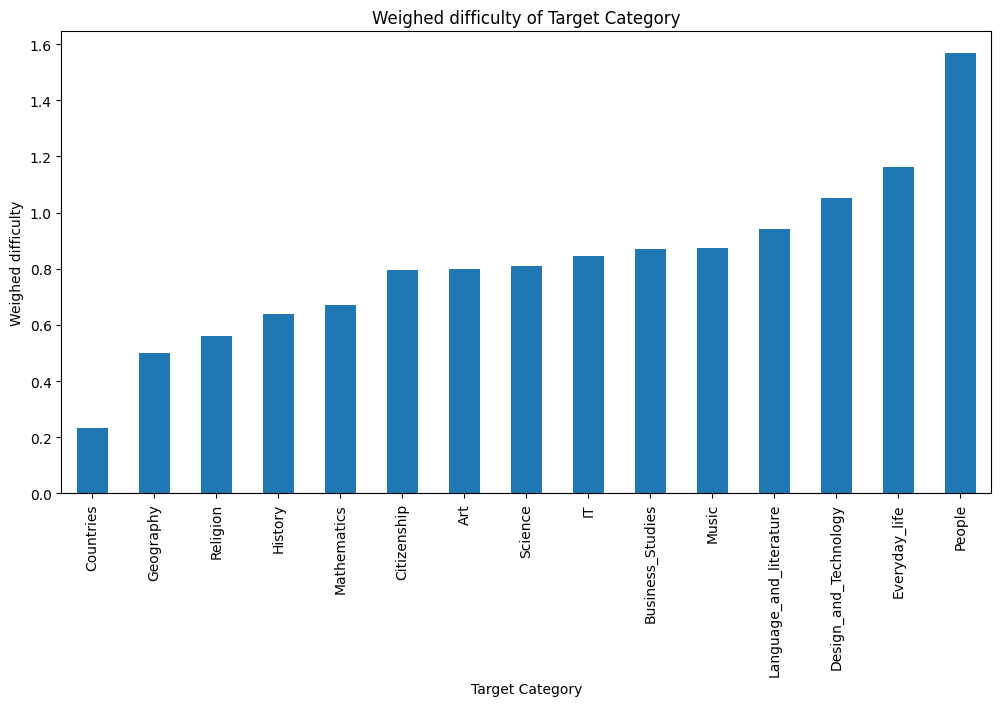

In [17]:
target_rating_rank = T_weighed_rating.rank(ascending=False).sort_values()


# Bar plot for target categories
T_weighed_rating.sort_values().plot(kind='bar', figsize=(12, 6))
plt.title("Weighed difficulty of Target Category")
plt.xlabel("Target Category")
plt.ylabel("Weighed difficulty")
plt.show()

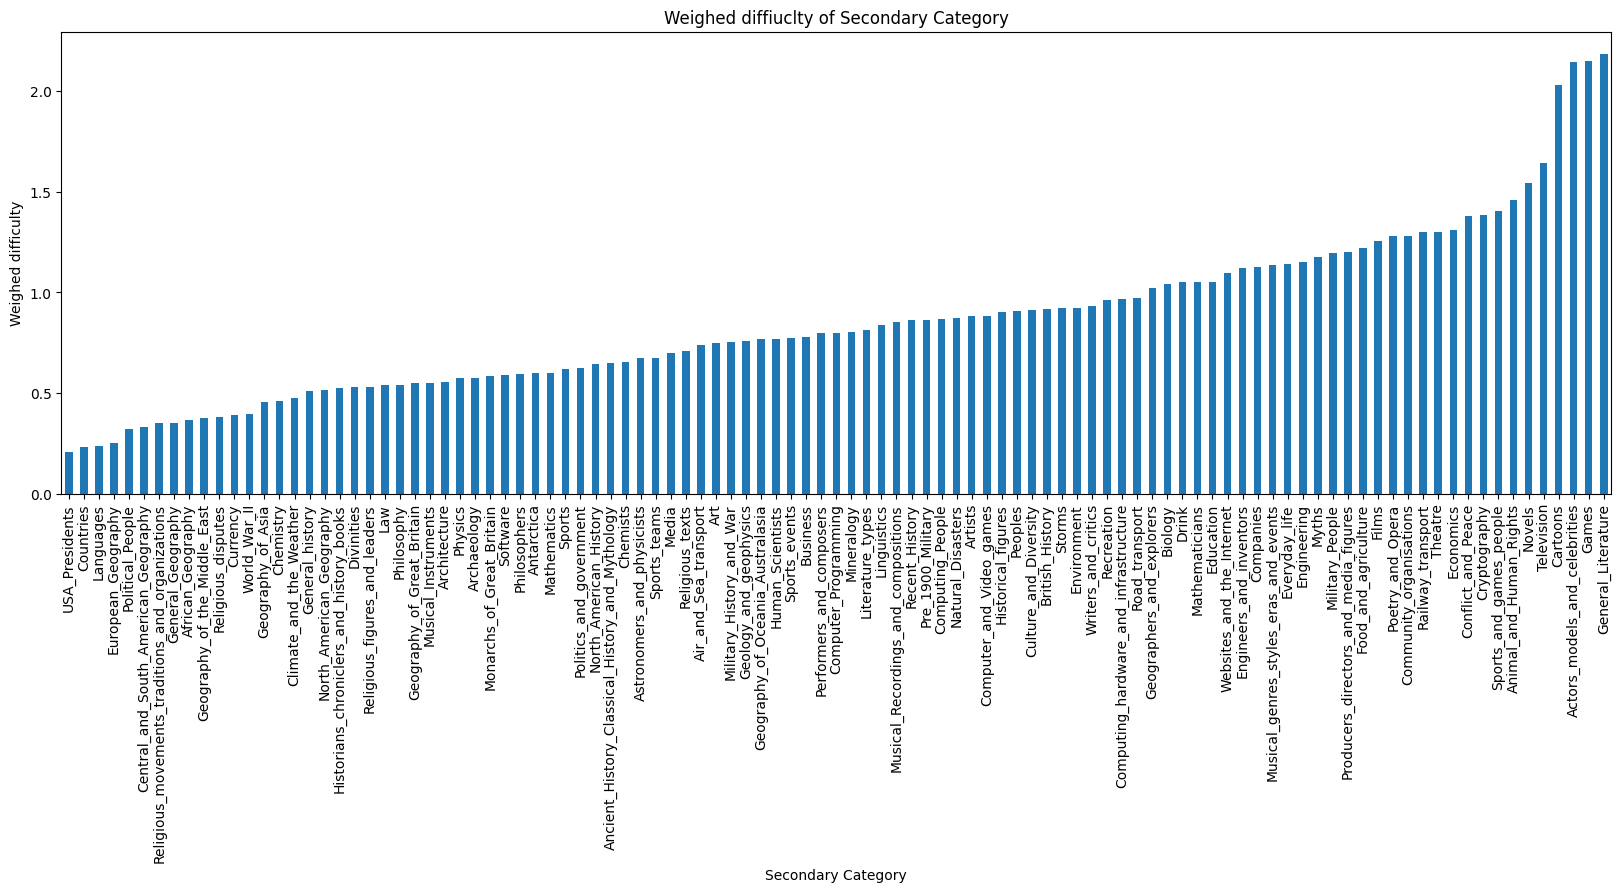

In [16]:
S_rating_rank = S_weighed_rating.rank(ascending=False).sort_values()


# Bar plot for target categories
S_weighed_rating.sort_values().plot(kind='bar', figsize=(20, 6))
plt.title("Weighed diffiuclty of Secondary Category")
plt.xlabel("Secondary Category")
plt.ylabel("Weighed difficulty")
plt.show()